# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [2]:
#seu código aqui
#Carregando as bases
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

In [3]:
X_test

,Age,Income,Number of Children,Marital Status_Single,Home Ownership_Rented,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,25.0,5500000.0,0,1,1,0,1,0,0,0
1,48.0,8750000.0,1,0,0,0,0,1,0,0
2,26.0,5500000.0,1,0,0,0,1,0,0,0
3,39.0,6250000.0,2,0,0,0,1,0,0,0
4,35.0,9000000.0,1,0,0,0,0,1,0,0
5,25.0,5500000.0,0,1,1,0,1,0,0,0
6,48.0,8250000.0,1,0,0,0,0,1,0,0
7,48.0,8250000.0,1,0,0,0,0,1,0,0
8,36.0,9500000.0,2,0,0,0,0,0,0,1
9,37.0,9500000.0,1,0,0,0,0,0,1,0


In [4]:
y_test

,Credit Score
0,Average
1,High
2,Average
3,High
4,High
5,Average
6,High
7,High
8,High
9,High


In [5]:
y_train

,Credit Score
0,Average
1,Low
2,Average
3,Average
4,Average
...,...
118,High
119,Average
120,High
121,High


In [6]:
# Verificando se os dados estão ajustados
contagem_classes = y_test.value_counts()

print("Contagem de amostras por classe:")
print(contagem_classes)

Contagem de amostras por classe:
Credit Score
High            29
Average          6
Low              6
Name: count, dtype: int64


In [7]:
X_train

,Age,Income,Number of Children,Marital Status_Single,Home Ownership_Rented,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,26.0,4500000.0,0,1,1,0,0,0,0,0
1,29.0,2750000.0,0,1,1,0,0,0,1,0
2,25.0,6250000.0,0,1,1,0,1,0,0,0
3,29.0,6800000.0,2,0,0,0,0,1,0,0
4,31.0,6500000.0,0,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
118,46.0,9750000.0,1,0,0,0,0,0,1,0
119,32.0,5750000.0,0,1,1,1,0,0,0,0
120,37.0,7000000.0,2,0,0,0,1,0,0,0
121,37.0,8500000.0,1,0,0,0,0,1,0,0


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

# Sua resposta aqui
- Primeiro nos importamos todas as bibliotecas necessárias
- Depois importamos a nossa base de dados no formato que ela estiver salva(csv,xlm,sql...etc)
- Verificamos os tipos das variaveis e se eles necessitam ser alterados ex: Object para int ou float
- Verificamos dados nulos ou faltantes e quanto em porcentagem esses dados representam do total dos nossos dados
- Agora na segunda etapa realizamos uma análise univariada de para encontrar possiveis outliers que possam enviesar o nosso modelo
- Se esses outliers forem encontrados devemos tratar da maneira mas adequada seja removendo, tratando ou até mesmo mantendo
- Agora fazemos a análise bivariada para retirarmos mais insights da comparação de duas variáveis
- A terceira etapa do pré processamento consiste em encontrar a correlação entre estes dados podendo ser feita através da matriz de correlação
- Após isso separamos a nossa variável que vai ser predita do resto da nossa base e treinamos o modelo
- Agora separamos os nossos dados em treino e teste para garantir que o modelo será testado em dados que ele nunca viu evitando overfitting
- Agora começamos a implementar o nosso modelo de árvore de decisão começando pela base de treino, onde podemos ajustar para critérios como gini ou entropy
- Uma vez treinado o modelo podemos aplicar na base de testes e começar as previsões
- Após rodar o modelo nas bases de treino e teste podemos avaliar as métricas como F1 - Score, Recall, Acuracy e precisão para sabermos se os valores encontrados são satisfatorios ou não
- Caso os valores encontrados nas avaliações ainda sejam insatisfatórios podemos verificar as features mais importantes para o nosso modelo reduzindo as caracteristicas e melhorando a generalização
- Além da redução de features podemos aplicar também a poda limitando a profundidade máxima evitando que ela fique complexa demais
- Também podemos aplicar a hiperparametrização com max_depth, min_sample_split, min_sample_leaf e criterion 
- Por fim treinamos novamente agora somente com as principais features e avaliamos as métricas novamente para podermos comparar com as métricas antes de reduzirmos

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [8]:
#seu código aqui
#Aplicando o algoritimo nos dados de treino
arvore_credito = DecisionTreeClassifier (criterion = 'gini', random_state = 0)

arvore_credito.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
previsoes = arvore_credito.predict(X_train)
acuracia = accuracy_score(y_train, previsoes)
print("Acurácia:", acuracia)

Acurácia: 1.0


In [10]:
#Plotando um relatório de calssificação para comparação com a bse de testes
previsoes = arvore_credito.predict(X_train)

relatorio_treino = classification_report(y_train, previsoes)
print("Relatório de Classificação:")
print(relatorio_treino)

Relatório de Classificação:
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00        30
        High       1.00      1.00      1.00        84
         Low       1.00      1.00      1.00         9

    accuracy                           1.00       123
   macro avg       1.00      1.00      1.00       123
weighted avg       1.00      1.00      1.00       123



# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [11]:
#seu código aqui
previsoes = arvore_credito.predict(X_test)
previsoes

array(['Average', 'High', 'Average', 'High', 'High', 'Average', 'High',
       'High', 'High', 'High', 'Average', 'Low', 'High', 'High', 'Low',
       'High', 'Average', 'Low', 'High', 'High', 'High', 'Low', 'Low',
       'High', 'High', 'High', 'High', 'High', 'Average', 'Average',
       'High', 'High', 'High', 'High', 'High', 'High', 'High', 'Average',
       'High', 'Low', 'High'], dtype=object)

In [12]:
y_test

,Credit Score
0,Average
1,High
2,Average
3,High
4,High
5,Average
6,High
7,High
8,High
9,High


In [14]:
relatorio_teste = classification_report(y_test, previsoes)
print("Relatório de Classificação:")
print(relatorio_teste)

Relatório de Classificação:
              precision    recall  f1-score   support

     Average       0.75      1.00      0.86         6
        High       1.00      0.93      0.96        29
         Low       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.92      0.98      0.94        41
weighted avg       0.96      0.95      0.95        41



De acordo com analise feita os valores seguem bem proximos tendo números bem altos como uma precisão de 0.75, um recall de 1.0 significando que todas as instâncias daquela classe foram recuperadas, mas ainda podem existir falsos positivos  e um F1-Score de 0.86 indicando que o modelo se ajustou bem aos dados de treino e teste conseguindo fazer previsões bem acertivas.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

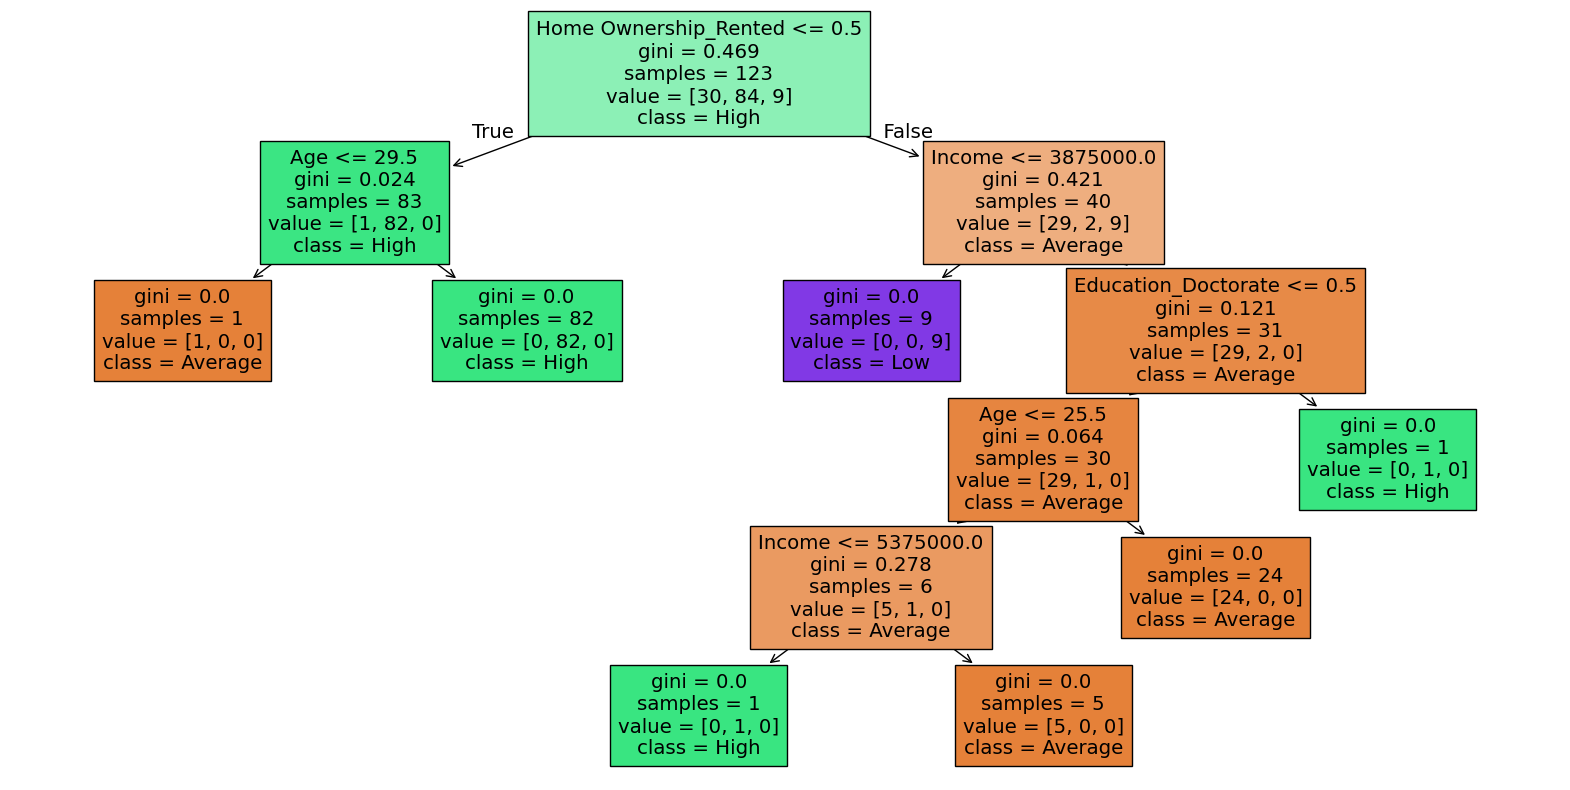

In [15]:
#seu código aqui
plt.figure(figsize=(20,10))
plot_tree(arvore_credito, filled=True, feature_names=X_train.columns, class_names=['Average', 'High','Low'])
plt.show()

Sim é possível fazer uma analise visual da arvore na qual se constata que a profundidade dela é 4

# 6) Identifique as 2 principais features do modelo.


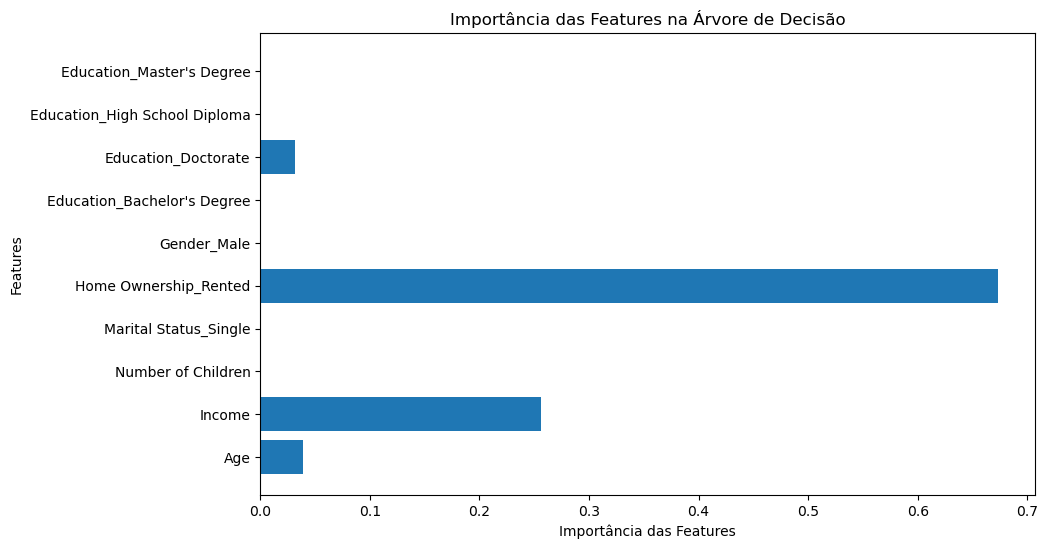

In [16]:
#seu código aqui
importancias_features = arvore_credito.feature_importances_

# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

As duas principais variáveis encontradas foram o income, e se a casa é alugada

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [17]:
#seu código aqui
X_train_reduzido = X_train[['Income', 'Home Ownership_Rented']]
X_test_reduzido = X_test[['Income', 'Home Ownership_Rented']]

In [18]:
arvore_credito_reduzida = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
arvore_credito_reduzida.fit(X_train_reduzido, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
previsoes_reduzido = arvore_credito_reduzida.predict(X_test_reduzido)

In [20]:
relatorio = classification_report(y_test, previsoes_reduzido)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

     Average       0.83      0.83      0.83         6
        High       0.97      0.97      0.97        29
         Low       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



Ao treinar a árvore de decisão utilizando apenas as duas features mais importantes, observa-se que o modelo mantém um desempenho satisfatório, embora apresente uma leve redução em algumas métricas, como o recall de uma das classes.

Essa redução indica que, apesar do modelo se tornar mais simples e interpretável, há uma pequena perda de sensibilidade na identificação de determinados casos. Ainda assim, o desempenho geral permanece adequado, demonstrando um trade-off entre simplicidade do modelo e capacidade preditiva.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

#Seu texto aqui
- Na minha avaliação os resultado obtidos são basicamente iguais nos dois modelos com a árvore de decisão sendo ligeiramente melhor cerca de 0.01 para alguma métricas do que o modelo de Naive Bayes
- Dessa forma, conclui-se que a Árvore de Decisão é mais adequada para esse problema específico, pois se ajusta melhor à estrutura dos dados e apresenta melhor desempenho preditivo geral